# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
from __future__ import annotations

import torch
from torch import nn

In [3]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        # Initialize parameters
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)
        
        # Xavier uniform initialization
        nn.init.xavier_uniform_(self.weight)
        if bias:
            nn.init.zeros_(self.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        # Implement y = x @ W^T + b
        out = x @ self.weight.T
        if self.bias is not None:
            out = out + self.bias
        return out

In [4]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        # TODO: initialize
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        # TODO: implement (index into weight)
        return self.weight[idx]

In [5]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # TODO: implement without using nn.Dropout
        if self.training:
            mask = (torch.rand_like(x) > self.p).float() / (1 - self.p)
            return x * mask
        else:
            return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [6]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        # TODO: implement
        self.normalized_shape = normalized_shape
        self.eps = eps
        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.register_parameter('weight', None)
            self.register_parameter('bias', None)
            
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        # TODO: implement
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if self.weight is not None:
            x_normalized = x_normalized * self.weight
        if self.bias is not None:
            x_normalized = x_normalized + self.bias
        return x_normalized

In [7]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        # TODO: implement
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        # TODO: implement
        mean_square = x.pow(2).mean(dim=-1, keepdim=True)
        x_normalized = x / torch.sqrt(mean_square + self.eps)
        return x_normalized * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [8]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        layers = []
        for i in range(depth):
            if i == 0:
                layers.append(Linear(in_dim, hidden_dim))
            else:
                layers.append(Linear(hidden_dim, hidden_dim))
            if use_layernorm:
                layers.append(LayerNorm(hidden_dim))
            layers.append(nn.ReLU())
        layers.append(Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.net(x)

In [9]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.net = nn.Sequential(
            Linear(d_model, d_ff),
            nn.GELU(),
            Linear(d_ff, d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.net(x)

In [10]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        # TODO: implement
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [12]:
# Fix SSL certificate issue on macOS
import ssl
import urllib.request

# Create unverified context for urllib
ssl._create_default_https_context = ssl._create_unverified_context

# Also patch urllib opener
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl._create_unverified_context()))
urllib.request.install_opener(opener)

transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

# Try to load/download MNIST dataset
try:
    train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
except Exception as e:
    print(f"Download failed: {e}")
    print("Trying to load existing data...")
    # Try loading without download if data exists
    train_ds = datasets.MNIST(root="data", train=True, download=False, transform=transform)
    test_ds  = datasets.MNIST(root="data", train=False, download=False, transform=transform)

# Define the dataloaders
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Train dataset size: {len(train_ds)}")
print(f"Test dataset size: {len(test_ds)}")

Train dataset size: 60000
Test dataset size: 10000


In [13]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # TODO: implement
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    loss = -log_probs[torch.arange(logits.size(0)), targets].mean()
    return loss

In [14]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # TODO: implement
        self.net = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        # TODO: implement
        return self.net(x)
    

In [15]:
def accuracy(loader):
    # TODO: You can use this function to evaluate your model accuracy.
    # Return the accuracy in [0,1].
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs = inputs.view(inputs.size(0), -1)  # Flatten images
        logits = model(inputs)  # Get logits from the model
        preds = torch.argmax(logits, dim=-1)  # Get predicted classes
        correct += (preds == targets).sum().item()  # Count correct predictions
        total += targets.size(0)  # Count total samples
    return correct / total  # Return accuracy as a fraction

In [16]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    # TODO: implement
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs): 
        model.train()
        for inputs, targets in train_data_loader:
            inputs = inputs.view(inputs.size(0), -1)  # Flatten images
            logits = model(inputs)
            loss = cross_entropy_from_logits(logits, targets)
            losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        model.eval()
        acc = accuracy(test_data_loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Accuracy: {acc:.4f}")
    return losses

## Results: Train the classifier and plot results

Run the cell below to build the MLP classifier, train it, and then visualize the training loss curve and final accuracy.

> **Note:** Remove the `matplotlib` import before submitting to the autograder.

In [ ]:
# import matplotlib.pyplot as plt  # NOTE: remove before submitting to autograder

# # Build classifier: MLP backbone + classification head
# in_dim = 784        # 28*28 flattened MNIST
# hidden_dim = 256
# num_classes = 10

# backbone = MLP(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=hidden_dim, depth=2)
# head = ClassificationHead(d_in=hidden_dim, num_classes=num_classes)
# model = nn.Sequential(backbone, head)

# # Train
# losses = train_classifier(
#     model=model,
#     train_data_loader=train_dl,
#     test_data_loader=test_dl,
#     lr=1e-3,
#     epochs=5,
# )

# # Final accuracy
# model.eval()
# final_acc = accuracy(test_dl)
# print(f"\nFinal test accuracy: {final_acc:.2%}")

Epoch 1/5, Loss: 0.1272, Test Accuracy: 0.9609
Epoch 2/5, Loss: 0.1029, Test Accuracy: 0.9710
Epoch 3/5, Loss: 0.0799, Test Accuracy: 0.9745
Epoch 4/5, Loss: 0.0080, Test Accuracy: 0.9769
Epoch 5/5, Loss: 0.0573, Test Accuracy: 0.9729

Final test accuracy: 97.29%


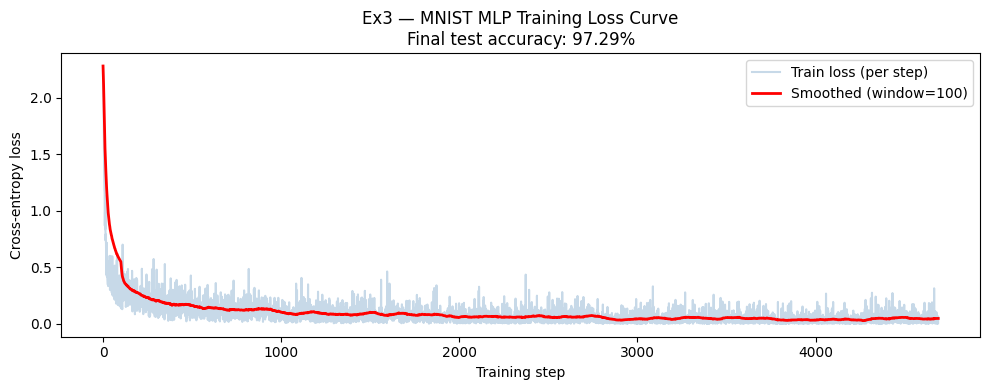

Saved → ex3_training_curve.png


In [ ]:
# # Plot training loss curve
# fig, ax = plt.subplots(figsize=(10, 4))

# ax.plot(losses, alpha=0.3, color="steelblue", label="Train loss (per step)")

# # Smoothed running average
# window = 100
# smoothed = [
#     sum(losses[max(0, i - window): i + 1]) / len(losses[max(0, i - window): i + 1])
#     for i in range(len(losses))
# ]
# ax.plot(smoothed, color="red", linewidth=2, label=f"Smoothed (window={window})")

# ax.set_xlabel("Training step")
# ax.set_ylabel("Cross-entropy loss")
# ax.set_title(f"Ex3 — MNIST MLP Training Loss Curve\nFinal test accuracy: {final_acc:.2%}")
# ax.legend()
# plt.tight_layout()
# plt.savefig("ex3_training_curve.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → ex3_training_curve.png")
